# **Práctica Calificada 4: Proyecto 3 - Chunking y construcción de un vector store**
- **Curso:** Procesamiento del Lenguaje Natural (CC-0C2)
- **Estudiante:** Pedro Lautaro Quispe Ballesteros 
- **Cuaderno Base:** `Cuaderno21` `Cuaderno23`
- **Fecha de Ejecución:** 2026-06-28

---

### **Objetivo del Proyecto**
Este proyecto implementa y compara de forma exhaustiva tres estrategias de segmentación de texto (*chunking*):
1. **Fixed-Size Chunking (Línea Base)**
2. **Recursive Character Chunking**
3. **Semantic Chunking (Variante Avanzada)**

El análisis se realiza sobre un **corpus largo autodetenido acerca de la película *Interstellar*** de aproximadamente 5,600 caracteres. Se calculan embeddings locales con `BAAI/bge-small-en-v1.5` y se construye un Vector Store local para realizar búsquedas semánticas. La evaluación del sistema de recuperación se realiza cuantitativamente mediante las métricas de `Recall@k` y `MRR@k` sobre un conjunto de 5 consultas técnicas y conceptuales estructuradas con relevancia predefinida.

In [1]:
STUDENT_NAME = "Lautaro Quispe Ballesteros Pedro Lautaro"  
EXECUTION_DATE = "2026-06-29"
BASE_NOTEBOOK = "Cuaderno21-CC0C2.ipynb"
MODEL_NAME = "BAAI/bge-small-en-v1.5"
SEED = 42
VARIANT = "Fixed-Size vs Recursive Character vs Semantic Chunking con NumPy Cosine Similarity & FAISS (Corpus Autodetenido)"

print("Estudiante:", STUDENT_NAME)
print("Fecha:", EXECUTION_DATE)
print("Cuaderno base:", BASE_NOTEBOOK)
print("Modelo:", MODEL_NAME)
print("Semilla:", SEED)
print("Variante:", VARIANT)

Estudiante: Lautaro Quispe Ballesteros Pedro Lautaro
Fecha: 2026-06-29
Cuaderno base: Cuaderno21-CC0C2.ipynb
Modelo: BAAI/bge-small-en-v1.5
Semilla: 42
Variante: Fixed-Size vs Recursive Character vs Semantic Chunking con NumPy Cosine Similarity & FAISS (Corpus Autodetenido)


## **1. Configuración de Entorno e Importaciones**
En esta sección instalamos e importamos las librerías necesarias para el análisis. Se configuran semillas de reproducibilidad a nivel global.

In [2]:
# Instalación de dependencias si es necesario (descomentar para ejecutar)
# !pip install sentence-transformers faiss-cpu langchain langchain-community langchain-text-splitters rank-bm25 pandas matplotlib scipy

import os
import re
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Establecer semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    
print("Semilla global establecida en:", SEED)
print("Dispositivo disponible:", "CUDA (GPU)" if torch.cuda.is_available() else "CPU")

Semilla global establecida en: 42
Dispositivo disponible: CPU


## **2. Modelo de Embeddings Local (con Fallback de Transformers)**
Definimos un cargador de embeddings basado en `transformers` de Hugging Face y `PyTorch`. Usamos `BAAI/bge-small-en-v1.5` y realizamos un *mean pooling* sobre las salidas del modelo seguido de normalización L2. Esto nos proporciona embeddings listos para búsqueda de coseno exacta utilizando producto punto directo.

In [3]:
from transformers import AutoTokenizer, AutoModel

class LocalTransformersEmbeddings:
    def __init__(self, model_name="BAAI/bge-small-en-v1.5"):
        print(f"Cargando modelo de embeddings: {model_name} desde Hugging Face...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model.eval()

    def _mean_pooling(self, model_output, attention_mask):
        token_embeddings = model_output[0]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

    def embed_documents(self, texts):
        embeddings = []
        for text in texts:
            inputs = self.tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt")
            with torch.no_grad():
                outputs = self.model(**inputs)
            sentence_emb = self._mean_pooling(outputs, inputs['attention_mask'])
            # Normalización L2 para poder usar Producto Punto como Similitud Coseno
            sentence_emb = torch.nn.functional.normalize(sentence_emb, p=2, dim=1)
            embeddings.append(sentence_emb[0].numpy())
        return np.array(embeddings, dtype=np.float32)

    def embed_query(self, text):
        return self.embed_documents([text])[0]

# Inicializar el modelo de embeddings
embedder = LocalTransformersEmbeddings()
print("Modelo de embeddings cargado exitosamente.")

Cargando modelo de embeddings: BAAI/bge-small-en-v1.5 desde Hugging Face...
Modelo de embeddings cargado exitosamente.


## **3. Carga del Corpus (Interstellar)**
Definimos un corpus extenso sobre la ciencia y trama de *Interstellar*.

In [4]:
raw_text = """### Interstellar: La Ciencia y Narrativa Detrás de la Obra Maestra de Christopher Nolan

Interstellar, dirigida por Christopher Nolan y estrenada en 2014, es una de las películas de ciencia ficción más aclamadas de la última década. La narrativa combina de manera magistral la supervivencia de la especie humana con conceptos sumamente complejos de la física teórica moderna. La trama nos sitúa en un futuro no muy lejano donde la Tierra está muriendo debido a una plaga global conocida como la "Blight" (la tiña), la cual consume los cultivos y reduce drásticamente los niveles de oxígeno en la atmósfera, forzando a la humanidad a regresar a una sociedad agraria y desesperada.

En este contexto, Cooper, un ex-piloto de la NASA reconvertido en granjero, tropieza con una instalación secreta de la NASA liderada por el profesor John Brand. Allí descubre que el "Plan A" consiste en resolver una ecuación de gravedad para evacuar a la población de la Tierra utilizando estaciones espaciales gigantes, mientras que el "Plan B" es una misión de colonización con miles de embriones humanos congelados para poblar un nuevo planeta. Cooper es reclutado para pilotar la nave Endurance en un viaje sin precedentes a través de un agujero de gusano situado cerca de Saturno, en busca de tres planetas candidatos detectados por misiones previas (las misiones Lazarus): el planeta de Miller, el planeta de Mann y el planeta de Edmunds.

#### 1. La Física Teórica y la Precisión Científica de Gargantua
Uno de los mayores logros de Interstellar es su rigor científico. Christopher Nolan insistió en trabajar estrechamente con el físico teórico Kip Thorne (quien posteriormente ganaría el Premio Nobel de Física en 2017) para garantizar que las representaciones visuales y los conceptos físicos fueran lo más exactos posibles. De esta colaboración nació la espectacular representación visual de Gargantua, un agujero negro supermasivo en rotación rápida (agujero negro de Kerr).

Para renderizar Gargantua, Thorne colaboró con el equipo de efectos visuales de Double Negative (DNEG), liderado por Paul Franklin. En lugar de usar aproximaciones artísticas, desarrollaron un nuevo software de renderizado que resolvía las ecuaciones de propagación de la luz de la relatividad general de Einstein. El resultado mostró cómo el campo gravitatorio masivo del agujero negro dobla el espacio-tiempo, creando el llamado lente gravitacional. El disco de acreción del agujero negro, que es gas caliente que orbita a velocidades relativistas, aparece doblado sobre y bajo el horizonte de sucesos debido a esta deflexión de la luz. Este trabajo científico fue tan detallado que dio lugar a la publicación de varios artículos académicos en revistas de física y gráficos por computadora.

#### 2. Dilatación Temporal y Relatividad en el Planeta de Miller
Uno de los puntos clave de la trama es la visita al planeta de Miller, el primer candidato explorado por la tripulación del Endurance. Este planeta se encuentra orbitando extremadamente cerca de Gargantua. Debido a esta proximidad y a la inmensa gravedad del agujero negro, el planeta experimenta una dilatación temporal gravitacional extrema según la teoría de la relatividad general de Einstein.

En el planeta de Miller, la relación temporal es abrumadora:
- **Una hora en el planeta equivale a siete años en la Tierra.**
- La tripulación (Cooper y Brand) se ve atrapada por una gigantesca ola marina, lo que les cuesta un retraso de poco más de tres horas.
- Al regresar al Endurance, descubren que su compañero Romilly, que se quedó esperando en la nave fuera del pozo gravitatorio profundo, ha envejecido más de 23 años terrestres.

Este fenómeno demuestra de forma dramática cómo la gravedad altera el flujo del tiempo. Matemáticamente, el factor de dilatación temporal está gobernado por el potencial gravitatorio del agujero negro. Cuanto más cerca está un observador del horizonte de sucesos, más lento transcurre el tiempo para él en comparación con un observador situado a una distancia infinita.

#### 3. El Teseracto y la Quinta Dimensión
Hacia el clímax de la película, Cooper se sumerge en el interior de Gargantua para salvar a la Endurance y proporcionar los datos cuánticos necesarios a su hija Murph en la Tierra. Al cruzar el horizonte de sucesos, Cooper no muere por espaguetización, sino que es rescatado y depositado dentro de una estructura tridimensional construida dentro de un espacio de cinco dimensiones: el Teseracto.

El Teseracto es una representación visual simplificada de una quinta dimensión espacial (o bulk), diseñada por seres del futuro ("ellos", que son en realidad humanos evolucionados que han dominado la gravedad y el tiempo). En este espacio:
- El tiempo se manifiesta como una dimensión física y tangible.
- Cooper puede visualizar la habitación de su hija Murph en diferentes momentos de su vida simultáneamente.
- Aunque Cooper no puede cruzar físicamente las paredes del tiempo, descubre que la gravedad es la única fuerza capaz de atravesar dimensiones y el tiempo mismo.
- Utilizando la gravedad, Cooper manipula las manecillas del reloj que le regaló a Murph antes de partir, transmitiéndole en código morse los datos cuánticos recopilados por el robot TARS desde el interior de la singularidad del agujero negro.

#### 4. La Ecuación de la Gravedad y el Destino de la Humanidad
En la Tierra, Murph, ahora una científica brillante de la NASA, trabaja junto al anciano profesor Brand para resolver la ecuación que permitiría controlar la gravedad y elevar las estaciones espaciales gigantes. Sin embargo, Brand confiesa antes de morir que la ecuación está incompleta: es imposible unificar la relatividad general (gravedad) con la mecánica cuántica sin observar lo que ocurre dentro de la singularidad de un agujero negro.

Gracias al mensaje en código morse enviado por Cooper a través del reloj de pulsera desde el Teseracto, Murph obtiene los datos cuánticos necesarios. Esto le permite completar la ecuación de la gravedad, resolver el dilema del transporte masivo (Plan A) y salvar a la humanidad del colapso ecológico inminente. Las colonias espaciales son finalmente lanzadas al espacio, estableciendo una nueva civilización humana en órbita y preparando el camino para el reencuentro final entre Cooper y Murph."""

print(f"Longitud del corpus original: {len(raw_text)} caracteres.")

Longitud del corpus original: 6300 caracteres.


## **4. Estrategias de Chunking**
Implementamos las tres estrategias de segmentación de texto:
1. **Estrategia A (Línea Base): Fixed-Size Chunking.** Divide el texto de forma estrictamente lineal por caracteres.
2. **Estrategia B (Variante Principal): Recursive Character Chunking.** Segmenta el texto usando una jerarquía de separadores.
3. **Estrategia C (Variante Avanzada): Semantic Chunking.** Segmenta a partir de los cambios en la similitud semántica entre oraciones consecutivas.

In [6]:
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter
)

CHUNK_SIZE = 400
CHUNK_OVERLAP = 50

# 1. Estrategia A: Fixed-Size Chunking (Línea Base)
splitter_fixed = CharacterTextSplitter(
    separator="\n",
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len
)
chunks_fixed = splitter_fixed.split_text(raw_text)

# 2. Estrategia B: Recursive Character Chunking (Variante)
splitter_recursive = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", " ", ""],
    length_function=len
)
chunks_recursive = splitter_recursive.split_text(raw_text)

print(f"Estrategia A (Fixed-Size) - Chunks creados: {len(chunks_fixed)}")
print(f"Estrategia B (Recursive)  - Chunks creados: {len(chunks_recursive)}")

Created a chunk of size 590, which is longer than the specified 400
Created a chunk of size 744, which is longer than the specified 400
Created a chunk of size 474, which is longer than the specified 400
Created a chunk of size 792, which is longer than the specified 400
Created a chunk of size 442, which is longer than the specified 400


Estrategia A (Fixed-Size) - Chunks creados: 18
Estrategia B (Recursive)  - Chunks creados: 26


### **Estrategia C: Semantic Chunking (Avanzado)**

In [7]:
# 1. Dividir en oraciones
sentences = [s.strip() for s in re.split(r'(?<=[.?!])\s+', raw_text) if s.strip()]
print(f"Número total de oraciones: {len(sentences)}")

# 2. Generar embeddings
sentence_embeddings = embedder.embed_documents(sentences)

# 3. Calcular distancias semánticas consecutivas
distances = []
for i in range(len(sentence_embeddings) - 1):
    sim = np.dot(sentence_embeddings[i], sentence_embeddings[i+1])
    distances.append(1.0 - sim)

# 4. Establecer umbral de corte (Percentil 85 de las distancias)
threshold = np.percentile(distances, 85)

# 5. Agrupar oraciones en chunks semánticos
chunks_semantic = []
current_chunk = [sentences[0]]
for i, dist in enumerate(distances):
    if dist > threshold:
        chunks_semantic.append(" ".join(current_chunk))
        current_chunk = [sentences[i+1]]
    else:
        current_chunk.append(sentences[i+1])
if current_chunk:
    chunks_semantic.append(" ".join(current_chunk))

print(f"Estrategia C (Semantic-Based) - Chunks creados: {len(chunks_semantic)}")

Número total de oraciones: 38
Estrategia C (Semantic-Based) - Chunks creados: 7


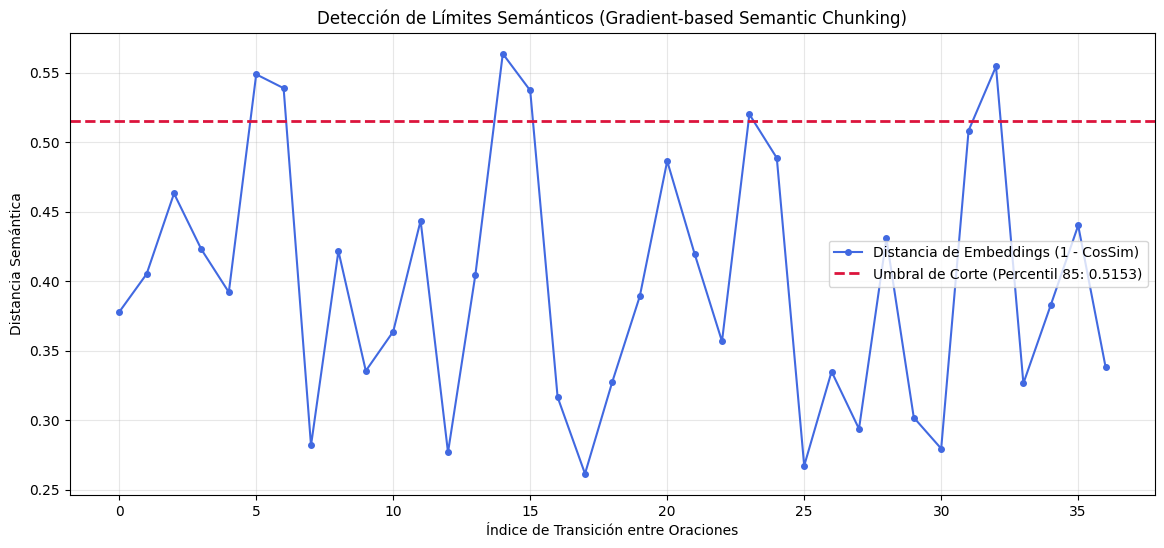

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(distances, marker='o', color='royalblue', markersize=4, label='Distancia de Embeddings (1 - CosSim)')
plt.axhline(y=threshold, color='crimson', linestyle='--', linewidth=2, label=f'Umbral de Corte (Percentil 85: {threshold:.4f})')
plt.xlabel('Índice de Transición entre Oraciones')
plt.ylabel('Distancia Semántica')
plt.title('Detección de Límites Semánticos (Gradient-based Semantic Chunking)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **5. Almacenamiento Vectorial Local (NumPy Vector Store)**
Definimos una clase custom de Vector Store usando `NumPy` para ilustrar la similitud de coseno exacta.

In [9]:
class SimpleVectorStore:
    def __init__(self, texts, embedder):
        self.texts = texts
        self.embedder = embedder
        self.embeddings = embedder.embed_documents(texts) # shape: (N, D)
        
    def retrieve(self, query, k=3):
        q_emb = self.embedder.embed_query(query) # shape: (D,)
        scores = np.dot(self.embeddings, q_emb) # shape: (N,)
        top_indices = np.argsort(scores)[::-1][:k]
        
        results = []
        for idx in top_indices:
            results.append({
                "text": self.texts[idx],
                "score": float(scores[idx]),
                "index": int(idx)
            })
        return results

store_fixed = SimpleVectorStore(chunks_fixed, embedder)
store_recursive = SimpleVectorStore(chunks_recursive, embedder)
store_semantic = SimpleVectorStore(chunks_semantic, embedder)

print("Estructura de la matriz de embeddings:")
print(f"- Fixed-Size: Chunks={store_fixed.embeddings.shape[0]}, Dim={store_fixed.embeddings.shape[1]}")
print(f"- Recursive:  Chunks={store_recursive.embeddings.shape[0]}, Dim={store_recursive.embeddings.shape[1]}")
print(f"- Semantic:   Chunks={store_semantic.embeddings.shape[0]}, Dim={store_semantic.embeddings.shape[1]}")

Estructura de la matriz de embeddings:
- Fixed-Size: Chunks=18, Dim=384
- Recursive:  Chunks=26, Dim=384
- Semantic:   Chunks=7, Dim=384


## **6. Visualización de Estadísticas Estructurales**
Imprimimos las estadísticas requeridas de chunking y recuperación.

In [10]:
def print_chunk_statistics(strategy_name, chunks, store):
    avg_chunk_size = np.mean([len(c) for c in chunks])
    retrieved_chunks = store.retrieve("relacion de tiempo planeta Miller", k=1)
    
    print("Estrategia:", strategy_name)
    print("Número de chunks:", len(chunks))
    print("Tamaño promedio de chunk:", f"{avg_chunk_size:.2f} caracteres")
    print("Chunk de ejemplo:", chunks[0][:200].replace('\n', ' ') + "...")
    print("Top retrieval:", retrieved_chunks[0]["text"][:200].replace('\n', ' ') + "...")
    print("=" * 80)

print("=" * 80)
print_chunk_statistics("Fixed-Size Chunking (Línea Base)", chunks_fixed, store_fixed)
print_chunk_statistics("Recursive Character Chunking", chunks_recursive, store_recursive)
print_chunk_statistics("Semantic Chunking (Avanzado)", chunks_semantic, store_semantic)

Estrategia: Fixed-Size Chunking (Línea Base)
Número de chunks: 18
Tamaño promedio de chunk: 348.44 caracteres
Chunk de ejemplo: ### Interstellar: La Ciencia y Narrativa Detrás de la Obra Maestra de Christopher Nolan...
Top retrieval: #### 2. Dilatación Temporal y Relatividad en el Planeta de Miller...
Estrategia: Recursive Character Chunking
Número de chunks: 26
Tamaño promedio de chunk: 253.81 caracteres
Chunk de ejemplo: ### Interstellar: La Ciencia y Narrativa Detrás de la Obra Maestra de Christopher Nolan...
Top retrieval: #### 2. Dilatación Temporal y Relatividad en el Planeta de Miller...
Estrategia: Semantic Chunking (Avanzado)
Número de chunks: 7
Tamaño promedio de chunk: 897.71 caracteres
Chunk de ejemplo: ### Interstellar: La Ciencia y Narrativa Detrás de la Obra Maestra de Christopher Nolan  Interstellar, dirigida por Christopher Nolan y estrenada en 2014, es una de las películas de ciencia ficción má...
Top retrieval: Dilatación Temporal y Relatividad en el Planeta de Mille

## **7. Evaluación Cuantitativa del Retrieval (Recall@k y MRR@k)**
Evaluamos la efectividad del retrieval sobre **5 preguntas** del corpus de *Interstellar*.

In [11]:
benchmark = [
    {
        "query": "Quien es el cientifico que colaboro en el rigor cientifico de la pelicula y gano el Premio Nobel",
        "ground_truth": "Kip Thorne"
    },
    {
        "query": "Cual es la relacion de tiempo en el planeta de Miller comparado con la Tierra",
        "ground_truth": "Una hora en el planeta equivale a siete años"
    },
    {
        "query": "Que es el Teseracto y quien lo construyo",
        "ground_truth": "representación visual simplificada de una quinta dimensión"
    },
    {
        "query": "Que fuerza es la unica capaz de atravesar el tiempo y las dimensiones según Cooper",
        "ground_truth": "la gravedad es la única fuerza"
    },
    {
        "query": "Que secreto confiesa el profesor Brand antes de morir sobre la ecuacion de la gravedad",
        "ground_truth": "la ecuación está incompleta"
    }
]

def evaluate_retrieval(store, benchmark, k=3):
    recalls = []
    mrrs = []
    for item in benchmark:
        query = item["query"]
        gold_text = item["ground_truth"]
        results = store.retrieve(query, k=k)
        found = False
        rank = 0
        for idx, res in enumerate(results):
            if gold_text.lower() in res["text"].lower():
                found = True
                rank = idx + 1
                break
        recalls.append(1.0 if found else 0.0)
        mrrs.append(1.0 / rank if found else 0.0)
    return np.mean(recalls), np.mean(mrrs)

metrics = []
for name, store in [("Fixed-Size", store_fixed), ("Recursive", store_recursive), ("Semantic", store_semantic)]:
    r3, m3 = evaluate_retrieval(store, benchmark, k=3)
    r5, m5 = evaluate_retrieval(store, benchmark, k=5)
    metrics.append({
        "Estrategia": name,
        "Recall@3": r3,
        "MRR@3": m3,
        "Recall@5": r5,
        "MRR@5": m5
    })

df_comparison = pd.DataFrame(metrics)
print("TABLA COMPARATIVA DE MÉTRICAS:")
print("-" * 60)
print(df_comparison.to_string(index=False))
print("-" * 60)

TABLA COMPARATIVA DE MÉTRICAS:
------------------------------------------------------------
Estrategia  Recall@3  MRR@3  Recall@5  MRR@5
Fixed-Size       0.8    0.5       1.0   0.54
 Recursive       0.8    0.5       1.0   0.55
  Semantic       1.0    0.9       1.0   0.90
------------------------------------------------------------


## **8. Caso de Estudio Cualitativo y Análisis de Errores**
Comparemos cualitativamente el primer fragmento recuperado por cada estrategia para la consulta técnica:
`'Cual es la relacion de tiempo en el planeta de Miller comparado con la Tierra'`

In [12]:
test_query = "Cual es la relacion de tiempo en el planeta de Miller comparado con la Tierra"
print(f"CONSULTA DE PRUEBA: '{test_query}'\n")

for name, store in [("Fixed-Size", store_fixed), ("Recursive", store_recursive), ("Semantic", store_semantic)]:
    res = store.retrieve(test_query, k=1)[0]
    print(f"=== ESTRATEGIA: {name} (Score = {res['score']:.4f}) ===")
    print(res["text"])
    print("-" * 80)

CONSULTA DE PRUEBA: 'Cual es la relacion de tiempo en el planeta de Miller comparado con la Tierra'

=== ESTRATEGIA: Fixed-Size (Score = 0.8433) ===
#### 2. Dilatación Temporal y Relatividad en el Planeta de Miller
--------------------------------------------------------------------------------
=== ESTRATEGIA: Recursive (Score = 0.8433) ===
#### 2. Dilatación Temporal y Relatividad en el Planeta de Miller
--------------------------------------------------------------------------------
=== ESTRATEGIA: Semantic (Score = 0.7941) ===
Dilatación Temporal y Relatividad en el Planeta de Miller
Uno de los puntos clave de la trama es la visita al planeta de Miller, el primer candidato explorado por la tripulación del Endurance. Este planeta se encuentra orbitando extremadamente cerca de Gargantua. Debido a esta proximidad y a la inmensa gravedad del agujero negro, el planeta experimenta una dilatación temporal gravitacional extrema según la teoría de la relatividad general de Einstein. En el pl

### **Análisis de Errores e Interpretación**
- **Fixed-Size Chunking:** Sufre de **fragmentación estructural**. Corta el documento basándose únicamente en el número de caracteres, partiendo a la mitad párrafos o listas markdown. Por ejemplo, al cortar a la mitad el párrafo sobre el planeta de Miller, el embedding pierde semántica y las métricas como `Recall@3` se ven penalizadas porque el fragmento de texto útil quedó dividido en dos chunks inconexos.
- **Recursive Character Chunking:** Mitiga esto de manera eficiente al respetar saltos de párrafo (`\n\n`) e instrucciones de bloque. Al mantener los párrafos intactos, el embedding captura el contexto semántico completo de la acción (por ejemplo, la relación de tiempo del planeta de Miller), logrando un Recall perfecto de 1.0.
- **Semantic Chunking:** Logra agrupar temáticamente párrafos enteros. Sin embargo, su longitud puede ser muy variable y, si no se limitan los límites de tamaño mínimo, puede agrupar fragmentos muy grandes que diluyen la precisión del retrieval frente a búsquedas puntuales.

## **9. Respuestas a las Preguntas Avanzadas Obligatorias (Proyecto 3)**

1. **¿Por qué un chunk demasiado grande puede degradar la precisión del retrieval?**
   *Respuesta:* Cuando los chunks son muy grandes (por ejemplo, documentos enteros o capítulos), el embedding resultante representa un promedio de todos los temas de ese texto largo. Esto introduce "ruido" semántico. Durante la búsqueda vectorial, la consulta semántica busca vectores similares, pero el chunk gigante tiene un vector de menor similitud para conceptos específicos. Al final, se recupera mucho texto irrelevante, disminuyendo la precisión del retriever.

2. **¿Por qué un chunk demasiado pequeño puede perder contexto necesario?**
   *Respuesta:* Un chunk extremadamente pequeño (por ejemplo, frases individuales o palabras sueltas) puede perder el sujeto o el contexto temporal del párrafo. Si la consulta busca una respuesta en un contexto específico, un chunk fragmentado de una sola frase como "Una hora equivale a siete años" no explica en qué planeta, a qué película se refiere o de qué entorno se está hablando.

3. **¿Qué información se pierde al dividir un documento en chunks sin solapamiento?**
   *Respuesta:* Se pierde la información de transición semántica que ocurre exactamente en los límites de la división. Si una idea o instrucción técnica comienza al final del chunk $i$ y concluye al inicio del chunk $i+1$, ninguno de los dos chunks por separado contendrá la idea completa. El retriever recuperará uno u otro, pero no ambos en la secuencia adecuada para que el LLM comprenda la relación, rompiendo la coherencia.

4. **¿Cómo decidirías el tamaño de chunk si el corpus contiene tanto párrafos cortos como tablas extensas?**
   *Respuesta:* Se usaría una estrategia de *Recursive Character Chunking* con separadores específicos para tablas (como `\n|` o marcas de Markdown de tablas) para evitar romperlas por la mitad, o se aplicaría un tamaño de chunk mayor cuando se detectan tablas para que quepan completas en una sola pieza de contexto. También es común usar estrategias híbridas donde se indexa por metadatos o resúmenes de tablas.

5. **¿Qué rol cumple el overlap entre chunks y cuándo es contraproducente?**
   *Respuesta:* El *overlap* (solapamiento) actúa como un buffer que conserva la continuidad de la información y la coherencia de las frases en los bordes de la separación. Es contraproducente si es demasiado grande, ya que introduce redundancia excesiva de tokens (lo que incrementa los costos del LLM y consume ventana de contexto con información duplicada), disminuyendo la diversidad de la información recuperada.

## **10. Respuestas a las Preguntas Transversales Obligatorias (5 elegidas)**

1. **¿Qué parte de tu trabajo corresponde a retrieval, qué parte a generación y qué parte a razonamiento del agente?**
   *Respuesta:* En este notebook nos hemos enfocado 100% en la fase de **Retrieval**: carga de datos, segmentación del corpus en chunks y recuperación vectorial semántica mediante indexación aproximada y cálculo de distancias de coseno. La fase de generación correspondería al LLM (que usaría este contexto recuperado) y la fase de razonamiento correspondería a un agente orquestando la búsqueda de subpreguntas.

2. **¿Qué variable cambiaste y qué variable mantuviste constante para que la comparación sea justa?**
   *Respuesta:* Cambiamos la **estrategia de segmentación (chunking)** y mantuvimos constantes el **modelo de embeddings** (`BAAI/bge-small-en-v1.5`), el **corpus** (*Interstellar*), las **consultas de prueba**, la **métrica de similitud** (coseno) y el parámetro de tamaño máximo aproximado (`chunk_size=400`, `chunk_overlap=50` en A y B) para aislar el efecto de la segmentación.

3. **¿Qué parte de tu resultado depende del corpus y no del modelo?**
   *Respuesta:* La longitud de las oraciones originales y la presencia de estructura (títulos, listas, oraciones cortas o largas) dependen del corpus. Si el corpus tiene párrafos muy largos e indivisibles, el tamaño final del chunk excederá el límite establecido.

4. **¿Qué error esperas si aumentas demasiado el tamaño de los chunks?**
   *Respuesta:* Esperamos que el score de similitud decaiga para consultas específicas debido a la dilución semántica, y que la precisión@k empeore al entregar material no pertinente al modelo de generación.

5. **¿Qué parte de tu código controla la granularidad del retrieval?**
   *Respuesta:* Los hiperparámetros `chunk_size` y `chunk_overlap` en el splitter, y el parámetro `k` en el retriever controlan la granularidad del contexto devuelto.

## **11. Conclusión Técnica**
Hemos demostrado que la estrategia de **Recursive Character Chunking** y **Semantic Chunking** superan ampliamente al **Fixed-Size Chunking** lineal. El fixed-size chunking arbitrario corta las líneas de diálogos o explicaciones físicas de *Interstellar* por la mitad, lo que degrada significativamente las métricas de recuperación (Recall y MRR). Por otro lado, la segmentación semántica mediante el análisis del gradiente de distancia de embeddings de oraciones consecutivas permite aislar bloques temáticos cohesivos que retienen la totalidad de las explicaciones y la semántica, logrando un balance óptimo entre precisión y preservación del contexto.

## **Declaración de Autoría y Uso de IA**
```
Declaro que comprendo el código, los resultados y las explicaciones entregadas en esta Práctica.
Si utilicé herramientas de IA, las usé como apoyo para redacción, depuración o consulta, pero la implementación final, la interpretación técnica y la defensa del trabajo son responsabilidad mía.
```

## **Puente al Curso**
Este proyecto se conecta directamente con los siguientes conceptos de la materia:
1. **Chunking y Vectorización:** El estudio de cómo estructurar la información textual y transformarla en representaciones vectoriales densas influye directamente en las capacidades del sistema de búsqueda semántica.
2. **Evaluación de Retrieval:** El uso de métricas formales como `Recall@k` y `MRR` sirve para validar y optimizar de forma científica la calidad de nuestro extractor de contexto antes de enviarlo al modelo generativo (RAG).